## Figure 4. Performance on ViT/T5

,model,method,acc
0,ViT-B-16,regmean,0.872425
1,ViT-B-16,tsv,0.888339
2,ViT-B-16,eigcov,0.895034


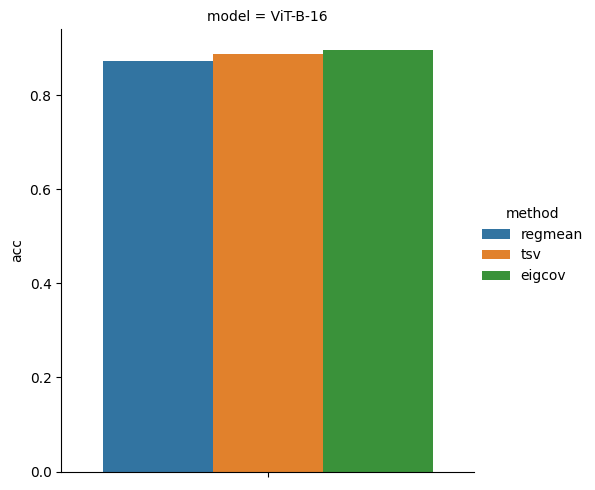

In [14]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns

methods = ["zeroshot", "experts", "regmean", "sum04", "mean", "isoc", "tsv", "eigcov"]
models = ["ViT-B-16", "ViT-L-14", "ViT-H-14"]
rows = []
for model in models:
    for method in methods:

        filename = f"../results/{model}-{method}/metrics.json"
        if not os.path.exists(filename):
            continue

        with open(f"../results/{model}-{method}/metrics.json", "r") as f:
            metrics = json.load(f)
            scores = [t["metrics"]["primary_score"] for t in metrics["tasks"]]
            avg_score = np.mean(scores)
            rows.append({"model": model, "method": method, "acc": avg_score})


df = pd.DataFrame(rows)
display(df)
sns.catplot(data=df, hue="method", y="acc", col="model", kind="bar")